In [ ]:
pip install numpy

In [ ]:
pip install pandas

In [ ]:
pip install matplotlib

In [ ]:
pip install mysql-connector-python

In [ ]:
pip install seaborn

In [7]:
import pandas as pd
import mysql.connector
import os

In [ ]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('order_items.csv', 'order_items'),
    ('payments.csv', 'payments')  # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='123456',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/ayush/Downloads/Project(Python+SQL)'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [9]:
db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='123456',
    database='ecommerce'
)
cursor = db.cursor()

In [35]:
#1. List all unique cities where customers are located.
query= """select distinct customer_city from customers"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


In [ ]:
#2. Count the number of orders placed in 2017.
query= """select count(order_id) from orders where year(order_purchase_timestamp)=2017"""
cursor.execute(query)
data=cursor.fetchall()
"Total orders places in year 2017 are:",data[0][0]

('Total orders places in year 2017 are:', 45101)

In [ ]:
#3. Find the total sales per category.
query= """select products.product_category Category, round(sum(payments.payment_value),2) Sales
from products join order_items
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by Category"""
cursor.execute(query)
data=cursor.fetchall()
data
df=pd.DataFrame(data, columns=["Category","Sales"])
df

,Category,Sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


In [23]:
#4. Calculate the percentage of orders that were paid in installments.
query= """select (sum(case when payment_installments>=1 then 1 else 0 end))/count(*)*100
from payments"""
cursor.execute(query)
data=cursor.fetchall()
data[0][0]

Decimal('99.9981')

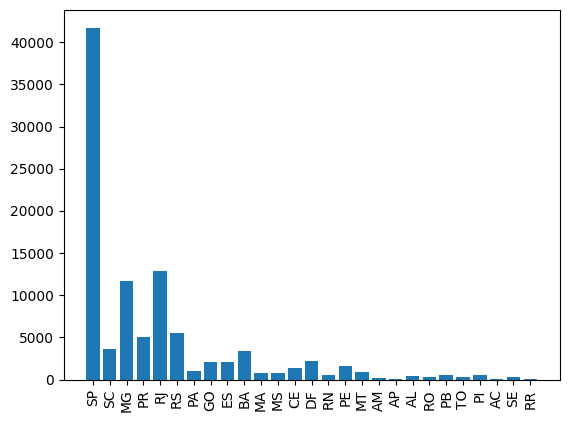

,State,Customer_count
0,SP,41746
1,SC,3637
2,MG,11635
3,PR,5045
4,RJ,12852
5,RS,5466
6,PA,975
7,GO,2020
8,ES,2033
9,BA,3380


In [34]:
#5. Count the number of customers from each state. 
query="""select customer_state, count(customer_id)
 from ecommerce.customers group by customer_state"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=["State","Customer_count"])
plt.bar(df["State"],df["Customer_count"])
plt.xticks(rotation=90)
plt.show()
df

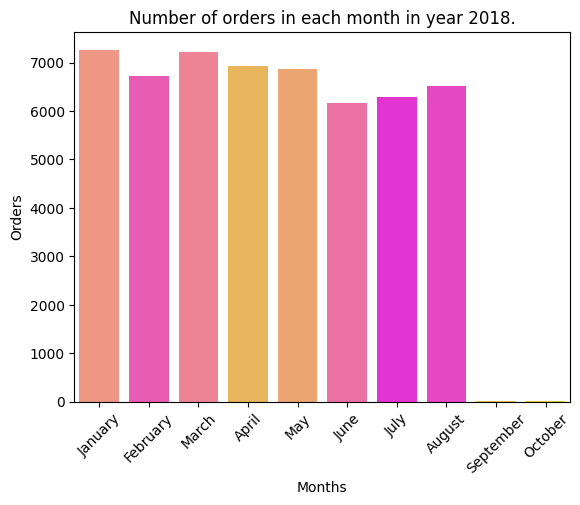

,Months,Orders
0,July,6292
1,August,6512
2,February,6728
3,June,6167
4,March,7211
5,January,7269
6,May,6873
7,April,6939
8,September,16
9,October,4


In [ ]:
#6. Calculate the number of orders per month in 2018.
query="""select monthname(order_purchase_timestamp) Months, count(order_id) Orders
 from orders where year(order_purchase_timestamp)=2018 group by Months"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=["Months","Orders"])
o=["January", "February", "March","April","May","June","July","August","September","October"]
sns.barplot(x=df["Months"],y=df["Orders"],data=df ,order=o, hue=df["Months"], palette="spring")
plt.xticks(rotation=45)
plt.title("Number of orders in each month in year 2018.")
plt.show()
df

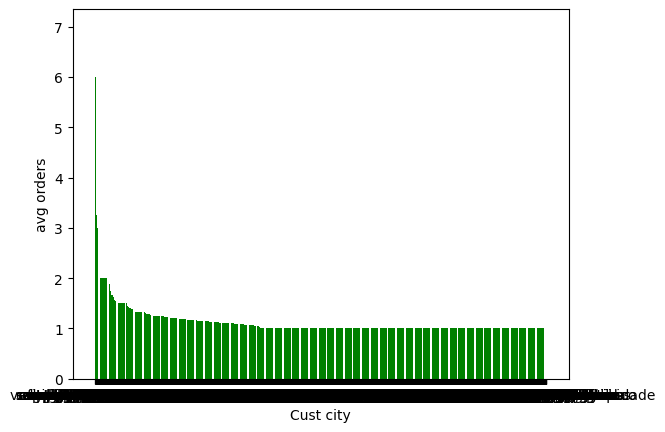

In [13]:
#7. Find the average number of products per order, grouped by customer city.
query="""with count_per_order as
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from ecommerce.orders join ecommerce.order_items
on orders.order_id=order_items.order_id
group by orders.order_id, orders.customer_id)
select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from ecommerce.customers join count_per_order
on customers.customer_id=count_per_order.customer_id
group by customers.customer_city order by average_orders desc"""
cursor.execute(query)
data=cursor.fetchall()
data
df=pd.DataFrame(data, columns=["Customer City","Average orders"])
df.head(10)
plt.bar(df["Customer City"],df["Average orders"], color='green')
plt.Figure(figsize=[40,62])
plt.xlabel("Cust city")
plt.ylabel("avg orders")
plt.show()


In [ ]:
#8. Calculate the percentage of total revenue contributed by each product category.
query= """select products.product_category Category, 
round(((sum(payments.payment_value))/(select sum(payment_value) from ecommerce.payments))*100,2)
Revenue_Percentage
from ecommerce.products join ecommerce.order_items
on products.product_id = order_items.product_id
join ecommerce.payments
on payments.order_id = order_items.order_id
group by Category order by Revenue_Percentage desc"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=["Category","Revenue_percentage"])
df


,Category,Revenue_percentage
0,bed table bath,10.70
1,HEALTH BEAUTY,10.35
2,computer accessories,9.90
3,Furniture Decoration,8.93
4,Watches present,8.93
...,...,...
69,House Comfort 2,0.01
70,cds music dvds,0.01
71,PC Gamer,0.01
72,Fashion Children's Clothing,0.00


In [ ]:
#9. Identify the correlation between product price and
#  the number of times a product has been purchased.
query="""select products.product_category, count(order_items.product_id),
round(avg(order_items.price),2) product_price
from ecommerce.products join ecommerce.order_items
on products.product_id=order_items.product_id
group by products.product_category"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=["Category","order_count","Price"])
print(df.head(10))
arr1=df["order_count"]
arr2=df["Price"]
a=np.corrcoef([arr1,arr2])
print("Since the correlation coefficient is", a[0][1],"there is no correlation between product price and" \
" the number of times a product has been purchased.")



               Category  order_count   Price
0         HEALTH BEAUTY         9670  130.16
1         sport leisure         8641  114.34
2            Cool Stuff         3796  167.36
3  computer accessories         7827  116.51
4       Watches present         5991  201.14
5            housewares         6964   90.79
6           electronics         2767   57.91
7                  None         1603  112.00
8                  toys         4117  117.55
9        bed table bath        11115   93.30
Since the correlation coefficient is -0.10631514167157562 there is no correlation between product price and the number of times a product has been purchased.


In [22]:
#10. Calculate the total revenue generated by each seller, and rank them by revenue.
query="""select *, rank() over(order by revenue desc) Ranking from
(select order_items.seller_id, round(sum(payments.payment_value),2) revenue
from ecommerce.order_items join ecommerce.payments
on order_items.order_id=payments.order_id
group by order_items.seller_id)as a"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=["Seller_id","Total_Revenue","Ranking"])
df


,Seller_id,Total_Revenue,Ranking
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301245.27,3
3,1f50f920176fa81dab994f9023523100,290253.42,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5
...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,19.21,3091
3091,702835e4b785b67a084280efca355756,18.56,3092
3092,4965a7002cca77301c82d3f91b82e1a9,16.36,3093
3093,77128dec4bec4878c37ab7d6169d6f26,15.22,3094


In [ ]:
#11. Calculate the moving average of order values for each customer over their order history.
query="""select customer_id, order_purchase_timestamp,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from 
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from ecommerce.payments join ecommerce.orders
on payments.order_id=orders.order_id) as a"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=["Customer_id","Purchase_Timestamp","Moving_Average"])
df

,Customer_id,Purchase_Timestamp,Moving_Average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.010002
...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000


In [25]:
#12. Calculate the cumulative sales per month for each year.
query="""select years, months, payment, sum(payment)
over(order by years, months) cumulative_sales from
(select year(orders.order_purchase_timestamp) as years,
 month(order_purchase_timestamp) as months,
 round(sum(payments.payment_value),2) as payment 
 from ecommerce.orders join ecommerce.payments
 on orders.order_id=payments.order_id
 group by years, months order by years,months) as a"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data,columns=["Years","Months","Sales","Cumulative_Sales"])
df

,Years,Months,Sales,Cumulative_Sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


In [ ]:
#13. Calculate the year-over-year growth rate of total sales.
query="""with a as(select year(orders.order_purchase_timestamp) as years,
 round(sum(payments.payment_value),2) as payment 
 from ecommerce.orders join ecommerce.payments
 on orders.order_id=payments.order_id
 group by years order by years)
 select years,payment, 
 ((payment-lag(payment,1) over(order by years))/lag(payment,1) over(order by years))*100 
 from a"""
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data,columns=["Years","Yearly_Sales","YOY % Growth"])
df


,Years,Yearly_Sales,YOY % Growth
0,2016,59362.34,NaN
1,2017,7249746.73,12112.703761
2,2018,8699763.05,20.000924


In [31]:
#14. Calculate the retention rate of customers, defined as the percentage of customers
#  who make another purchase within 6 months of their first purchase.
query=""" with a as (select customers.customer_id, 
 min(orders.order_purchase_timestamp) first_order
 from ecommerce.customers join ecommerce.orders
 on customers.customer_id=orders.customer_id
 group by customer_id),
b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
 from a join ecommerce.orders
 on a.customer_id=orders.customer_id
 and orders.order_purchase_timestamp> first_order
 and orders.order_purchase_timestamp< date_add(first_order, interval 6 month)
 group by a.customer_id) 
 select 100*(count(distinct a.customer_id)/count(distinct b.customer_id))
 from a left join b
 on a.customer_id=b.customer_id"""
cursor.execute(query)
data=cursor.fetchall()
print(data)
print("There are no customers who made another purchase in next 6 months.")


[(None,)]
There are no customers who made another purchase in next 6 months.


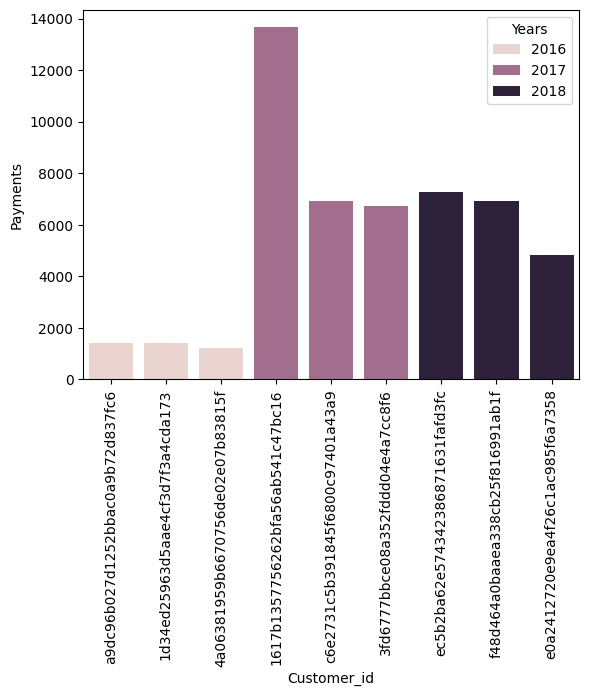

In [40]:
#15. Identify the top 3 customers who spent the most money in each year.
query="""select years, customer_id, payment, d_rank from
(select year(orders.order_purchase_timestamp) years,orders.customer_id, 
sum(payments.payment_value) payment,
dense_rank() over (partition by year(orders.order_purchase_timestamp)
 order by sum(payments.payment_value) desc) d_rank
from ecommerce.orders join ecommerce.payments
 on payments.order_id=orders.order_id
 group by year(orders.order_purchase_timestamp),orders.customer_id) as a
  where d_rank<=3 """
cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=["Years","Customer_id","Payments","Ranks"])
df
sns.barplot(x=df["Customer_id"], y=df["Payments"],data=df, hue="Years")
plt.xticks(rotation=90)
plt.show()